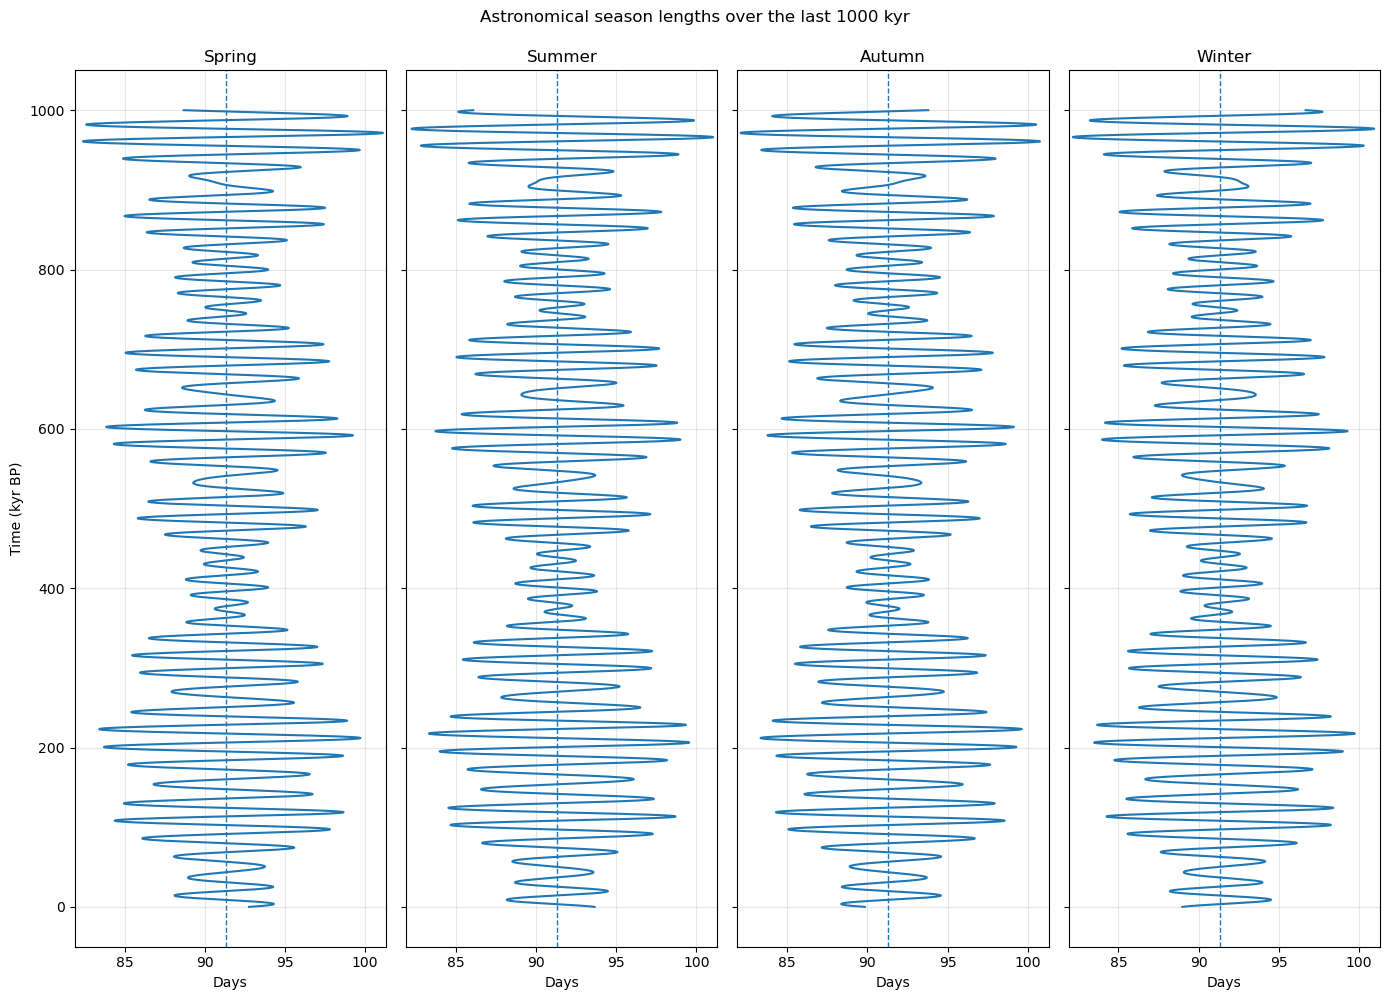

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from inso.astro import AstroLaskar2004
from inso.inso import length_of_season

year_days = 365.2425
kyr_bp_max = 1000
npts = 4001

kyr_bp = np.linspace(0, kyr_bp_max, npts)
t_kyr_ap = -kyr_bp

a = AstroLaskar2004()
ecc = np.array([a.eccentricity(t) for t in t_kyr_ap])
pre = np.array([a.precession_angle(t) for t in t_kyr_ap])

bounds = [0.0, 0.5*np.pi, 1.0*np.pi, 1.5*np.pi, 2.0*np.pi]
labels = ["Spring", "Summer", "Autumn", "Winter"]

season_lengths = []
for i in range(4):
    d = np.array([
        year_days * length_of_season(bounds[i], bounds[i+1], e, p)
        for e, p in zip(ecc, pre)
    ])
    season_lengths.append(d)

season_lengths = np.array(season_lengths)  # shape = (4, npts)

fig, axes = plt.subplots(1, 4, figsize=(14, 10), sharey=True)

xmin = season_lengths.min() - 0.2
xmax = season_lengths.max() + 0.2

for ax, data, lab in zip(axes, season_lengths, labels):
    ax.plot(data, kyr_bp)
    ax.axvline(year_days/4, linestyle="--", linewidth=1)
    ax.set_title(lab)
    ax.set_xlim(xmin, xmax)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    ax.set_xlabel("Days")

axes[0].set_ylabel("Time (kyr BP)")
fig.suptitle("Astronomical season lengths over the last 1000 kyr", y=0.995)
plt.tight_layout()
plt.show()

Mean total length: 365.242500 days
Min total length : 365.242500 days
Max total length : 365.242500 days


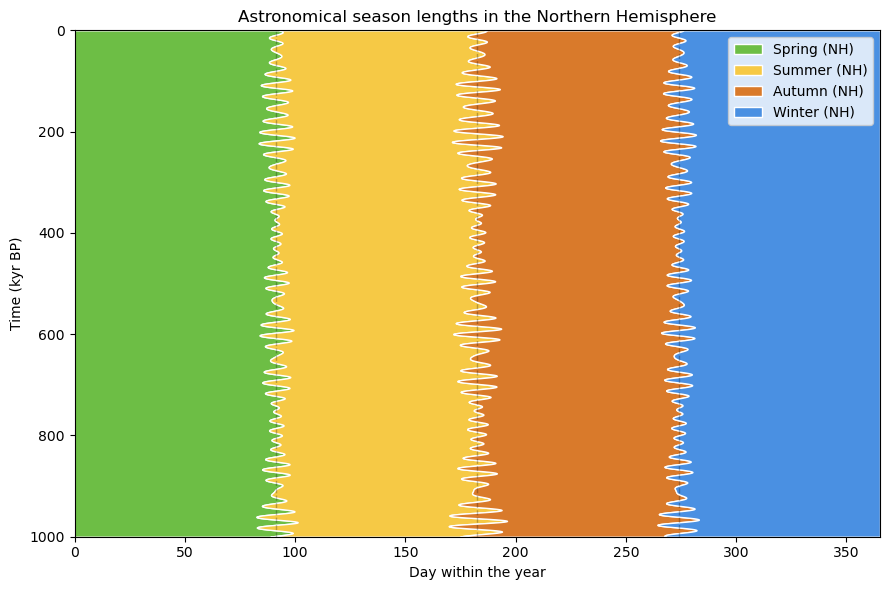

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from inso.astro import AstroLaskar2004
from inso.inso import length_of_season

# ---------------------------
# Parameters
# ---------------------------
year_days = 365.2425
kyr_bp_max = 1000
npts = 4001

kyr_bp = np.linspace(0, kyr_bp_max, npts)
t_kyr_ap = -kyr_bp  # past in kyr BP -> negative kyrAP

# ---------------------------
# Orbital solution
# ---------------------------
astro = AstroLaskar2004()

ecc = np.array([astro.eccentricity(t) for t in t_kyr_ap])
pre = np.array([astro.precession_angle(t) for t in t_kyr_ap])

# ---------------------------
# Season boundaries (NH astronomical seasons)
# ---------------------------
bounds = [0.0, 0.5 * np.pi, 1.0 * np.pi, 1.5 * np.pi, 2.0 * np.pi]
labels = ["Spring (NH)", "Summer (NH)", "Autumn (NH)", "Winter (NH)"]

# Representative NH seasonal colors
colors = [
    "#6DBE45",  # Spring: green
    "#F6C945",  # Summer: warm yellow
    "#D97A2B",  # Autumn: orange/brown
    "#4A90E2",  # Winter: blue
]

# ---------------------------
# Compute season lengths in days
# ---------------------------
seasons = []
for i in range(4):
    d = np.array([
        year_days * length_of_season(bounds[i], bounds[i + 1], e, p)
        for e, p in zip(ecc, pre)
    ])
    seasons.append(d)

seasons = np.array(seasons)  # shape = (4, npts)

# Optional check
total = seasons.sum(axis=0)
print(f"Mean total length: {total.mean():.6f} days")
print(f"Min total length : {total.min():.6f} days")
print(f"Max total length : {total.max():.6f} days")

# ---------------------------
# Build cumulative positions along the year axis
# ---------------------------
cum = np.cumsum(seasons, axis=0)

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(9, 6))

x0 = np.zeros_like(kyr_bp)

for i in range(4):
    x1 = cum[i]
    ax.fill_betweenx(
        kyr_bp,
        x0,
        x1,
        facecolor=colors[i],
        edgecolor="white",
        linewidth=1,
        label=labels[i],
    )
    x0 = x1

# Draw quarter-year reference lines
for xref in [year_days / 4, year_days / 2, 3 * year_days / 4]:
    ax.axvline(xref, color="k", linewidth=1, linestyle="--", alpha=0.25)

# ---------------------------
# Formatting
# ---------------------------
ax.set_xlim(0, year_days)
ax.set_ylim(kyr_bp_max, 0)  # present at top
ax.set_xlabel("Day within the year")
ax.set_ylabel("Time (kyr BP)")
ax.set_title("Astronomical season lengths in the Northern Hemisphere")

ax.legend(loc="upper right", frameon=True)
ax.grid(False)

plt.tight_layout()
plt.show()

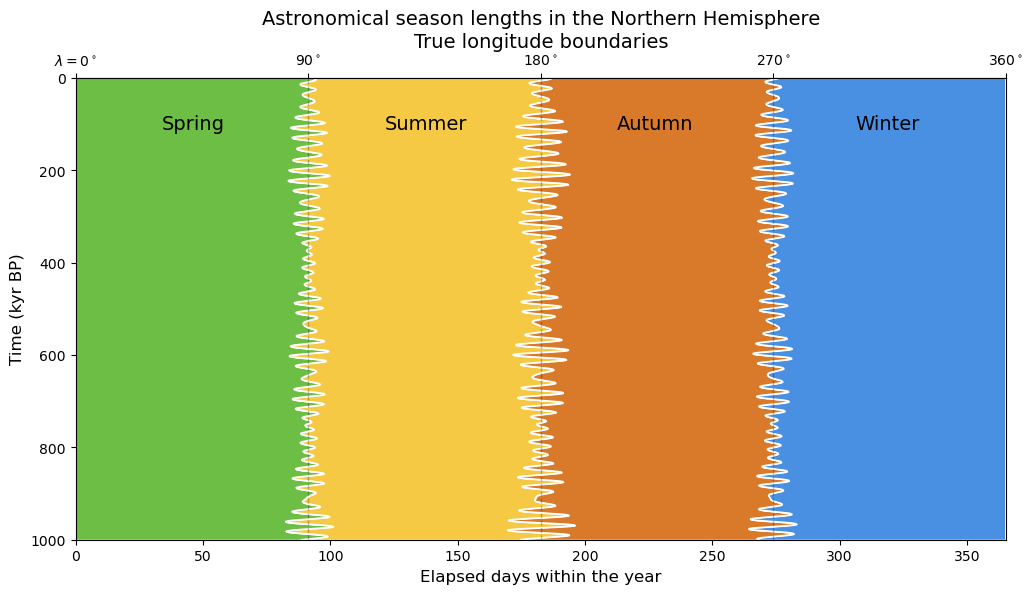

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from inso.astro import AstroLaskar2004
from inso.inso import length_of_season

# ---------------------------
# Parameters
# ---------------------------
year_days = 365.2425
kyr_bp_max = 1000
npts = 4001

kyr_bp = np.linspace(0, kyr_bp_max, npts)
t_kyr_ap = -kyr_bp

# ---------------------------
# Orbital solution
# ---------------------------
astro = AstroLaskar2004()

ecc = np.array([astro.eccentricity(t) for t in t_kyr_ap])
pre = np.array([astro.precession_angle(t) for t in t_kyr_ap])

# ---------------------------
# Season boundaries in true longitude (NH)
# ---------------------------
bounds = [0.0, 0.5 * np.pi, 1.0 * np.pi, 1.5 * np.pi, 2.0 * np.pi]
labels = ["Spring (NH)", "Summer (NH)", "Autumn (NH)", "Winter (NH)"]

colors = [
    "#6DBE45",  # Spring
    "#F6C945",  # Summer
    "#D97A2B",  # Autumn
    "#4A90E2",  # Winter
]

# ---------------------------
# Compute season lengths in days
# ---------------------------
seasons = []
for i in range(4):
    d = np.array([
        year_days * length_of_season(bounds[i], bounds[i + 1], e, p)
        for e, p in zip(ecc, pre)
    ])
    seasons.append(d)

seasons = np.array(seasons)

total = seasons.sum(axis=0)
#print(f"Mean total length: {total.mean():.6f} days")
#print(f"Min total length : {total.min():.6f} days")
#print(f"Max total length : {total.max():.6f} days")

# ---------------------------
# Cumulative boundaries in day-of-year coordinates
# ---------------------------
b0 = np.zeros_like(kyr_bp)
b1 = seasons[0]
b2 = seasons[0] + seasons[1]
b3 = seasons[0] + seasons[1] + seasons[2]
b4 = year_days * np.ones_like(kyr_bp)

boundaries = [b0, b1, b2, b3, b4]

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Filled seasonal bands
x0 = np.zeros_like(kyr_bp)
for i in range(4):
    x1 = boundaries[i + 1]
    ax.fill_betweenx(
        kyr_bp,
        x0,
        x1,
        facecolor=colors[i],
        edgecolor="white",
        linewidth=0.8,
        label=labels[i],
    )
    x0 = x1

# Explicit true-longitude boundaries
for b in boundaries:
    ax.plot(b, kyr_bp, color="white", linewidth=1.1)

# Equal-time quarter-year reference lines
for xref in [year_days / 4, year_days / 2, 3 * year_days / 4]:
    ax.axvline(
        xref,
        color="black",
        linewidth=1,
        linestyle="--",
        alpha=0.25,
    )

# ---------------------------
# Top axis with true-longitude labels
# ---------------------------
secax = ax.secondary_xaxis("top")
mean_positions = [
    np.mean(b0),
    np.mean(b1),
    np.mean(b2),
    np.mean(b3),
    np.mean(b4),
]
secax.set_xticks(mean_positions)
secax.set_xticklabels([
    r"$\lambda=0^\circ$",
    r"$90^\circ$",
    r"$180^\circ$",
    r"$270^\circ$",
    r"$360^\circ$",
])
secax.set_xlabel("True longitude boundaries", fontsize=14)

# ---------------------------
# Formatting
# ---------------------------
ax.set_xlim(0, year_days)
ax.set_ylim(kyr_bp_max, 0)
ax.set_xlabel("Elapsed days within the year")
ax.set_ylabel("Time (kyr BP)")
ax.set_title("Astronomical season lengths in the Northern Hemisphere", fontsize=14)

#ax.legend(loc="upper right", frameon=True)
y_text = 100
x_texts = [
    np.mean(b1[:50]) / 2,
    np.mean((b1[:50] + b2[:50]) / 2),
    np.mean((b2[:50] + b3[:50]) / 2),
    np.mean((b3[:50] + b4[:50]) / 2),
]
for x, txt in zip(x_texts, ["Spring", "Summer", "Autumn", "Winter"]):
    ax.text(x, y_text, txt, ha="center", va="center", fontsize=14, weight="normal")

ax.grid(False)
ax.xaxis.label.set_size(12)
ax.yaxis.label.set_size(12)

plt.savefig('season_length.png', dpi=140)

#plt.tight_layout()
plt.show()